In [20]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, InputLayer

ModuleNotFoundError: No module named 'distutils'

In [19]:

pip install --upgrade pip


  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install tensorflow


  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-14.1.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metad

In [11]:
pip install numpy matplotlib pandas pandas_datareader tensorflow scikit-learn keras


  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 13.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 11.6 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install numpy pandas matplotlib scikit-learn


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 9.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 8.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 9.3 MB/s eta 0:00:00a 0:00:01m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 11.0 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 10.3 MB/s eta 0:00

In [18]:
#------------------------------------------------------------------------------
# Production-Ready Multi-Feature Stock Data Loader
#------------------------------------------------------------------------------

import os
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def load_and_process_stock_data(
    company="CBA.AX",
    start_date="2020-01-01",
    end_date="2023-08-01",
    data_dir="data",
    handle_nan="drop",       # "drop", "ffill", "bfill", "mean"
    split_method="ratio",    # "ratio", "date", "random"
    split_value=0.8,         # float for ratio, string for date
    scale_features=True,
    scaler_type="standard",  # "standard" or "minmax"
    save_local=True,
    load_local=True
):
    """
    Load, clean, split, and scale stock data (multi-feature) with proper error handling.
    """

    #--------------------------------------------------------------
    # Step 0: Validate dates
    #--------------------------------------------------------------
    try:
        start_date = pd.to_datetime(start_date)
        end_date = pd.to_datetime(end_date)
    except Exception as e:
        raise ValueError(f"Invalid date format: {e}")
    
    if start_date >= end_date:
        raise ValueError("Start date must be earlier than end date.")

    #--------------------------------------------------------------
    # Step 1: Prepare local file path
    #--------------------------------------------------------------
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    csv_file = os.path.join(data_dir, f"{company}_stock_data.csv")

    #--------------------------------------------------------------
    # Step 2: Load dataset
    #--------------------------------------------------------------
    data = pd.DataFrame()
    if load_local and os.path.exists(csv_file):
        try:
            data = pd.read_csv(csv_file, index_col="Date", parse_dates=True)
            print(f"Loaded local file: {csv_file}")
        except Exception as e:
            print(f"Failed to load local file: {e}. Will attempt download.")

    if data.empty:
        try:
            data = yf.download(company, start=start_date, end=end_date)
            if data.empty:
                raise ValueError("Downloaded dataset is empty. Check ticker or date range.")
            if save_local:
                data.to_csv(csv_file)
                print(f"Downloaded and saved to {csv_file}")
        except Exception as e:
            raise ConnectionError(f"Failed to download data: {e}")

    #--------------------------------------------------------------
    # Step 3: Handle missing values
    #--------------------------------------------------------------
    if handle_nan == "drop":
        data = data.dropna()
    elif handle_nan == "ffill":
        data = data.ffill()
    elif handle_nan == "bfill":
        data = data.bfill()
    elif handle_nan == "mean":
        data = data.fillna(data.mean())
    else:
        raise ValueError("Invalid handle_nan option.")

    #--------------------------------------------------------------
    # Step 4: Feature scaling (per-column)
    #--------------------------------------------------------------
    scalers = {}
    if scale_features:
        scaled_data = pd.DataFrame(index=data.index)
        for col in data.columns:
            if scaler_type == "standard":
                scaler = StandardScaler()
            elif scaler_type == "minmax":
                scaler = MinMaxScaler()
            else:
                raise ValueError("Invalid scaler_type: 'standard' or 'minmax'")
            
            # Fit and transform single column
            scaled_data[col] = scaler.fit_transform(data[[col]])
            scalers[col] = scaler  # store scaler for this column
        data = scaled_data

    #--------------------------------------------------------------
    # Step 5: Train/Test Split
    #--------------------------------------------------------------
    if split_method == "ratio":
        split_idx = int(len(data) * split_value)
        train = data.iloc[:split_idx]
        test = data.iloc[split_idx:]
    
    elif split_method == "date":
        try:
            split_date = pd.to_datetime(split_value)
        except Exception as e:
            raise ValueError(f"Invalid split date: {e}")

        # Ensure no overlap: split_date included only in test
        train = data[data.index < split_date]
        test = data[data.index >= split_date]
    
    elif split_method == "random":
        train = data.sample(frac=split_value, random_state=42)
        test = data.drop(train.index)
    else:
        raise ValueError("Invalid split_method: 'ratio', 'date', 'random' only")

    return train, test, scalers


#------------------------------------------------------------------------------
# Example Usage
#------------------------------------------------------------------------------
if __name__ == "__main__":
    train_data, test_data, scalers = load_and_process_stock_data(
        company="CBA.AX",
        start_date="2020-01-01",
        end_date="2023-08-01",
        handle_nan="ffill",
        split_method="date",
        split_value="2023-01-01",
        scale_features=True,
        scaler_type="minmax",
        save_local=True,
        load_local=True
    )

    print("Train shape:", train_data.shape)
    print("Test shape:", test_data.shape)
    print(train_data.head())


/var/folders/n3/f5ytszns27bb7c95jm3qrfdh0000gn/T/ipykernel_27810/944385529.py:59: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(company, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Downloaded and saved to data/CBA.AX_stock_data.csv
Train shape: (760, 5)
Test shape: (145, 5)
            (Close, CBA.AX)  (High, CBA.AX)  (Low, CBA.AX)  (Open, CBA.AX)  \
Date                                                                         
2020-01-02         0.354186        0.322016       0.359309        0.335333   
2020-01-03         0.360431        0.336813       0.371800        0.352911   
2020-01-06         0.352589        0.316830       0.356985        0.334439   
2020-01-07         0.373355        0.336965       0.370783        0.350677   
2020-01-08         0.368998        0.337728       0.368604        0.356635   

            (Volume, CBA.AX)  
Date                          
2020-01-02          0.063919  
2020-01-03          0.076308  
2020-01-06          0.106688  
2020-01-07          0.123976  
2020-01-08          0.082087  


In [9]:
PRICE_VALUE = "Close"
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[PRICE_VALUE]].values)  # keep as 2D


In [10]:
PREDICTION_DAYS = 60  # Number of past days the model looks at
x_train, y_train = [], []

for i in range(PREDICTION_DAYS, len(scaled_data)):
    x_train.append(scaled_data[i-PREDICTION_DAYS:i])
    y_train.append(scaled_data[i])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


In [11]:
#-------------------- Build the LSTM Model --------------------#
model = Sequential()

# Input layer: shape matches number of past days used for prediction
model.add(InputLayer(input_shape=(x_train.shape[1], 1)))

# First LSTM layer with Dropout for regularization
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Second LSTM layer with Dropout
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Output layer: predicts a single value (next price)
model.add(Dense(1))

# Compile the model with optimizer and loss function
model.compile(optimizer='adam', loss='mean_squared_error')

#-------------------- Train the Model --------------------#
# We train the model on x_train, y_train
# validation_split=0.1 uses 10% of the training data for validation
# verbose=1 prints training progress
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

#-------------------- Save the Model --------------------#
# After training, save the model to reuse later without retraining
model.save("results/CBA_AX_model.h5")


/Users/lasithcharuka/hand/stockpred-env/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0875 - val_loss: 0.0208
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0105 - val_loss: 0.0032
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0074 - val_loss: 0.0012
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0070 - val_loss: 0.0018
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0063 - val_loss: 0.0011
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0063 - val_loss: 0.0022
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0062 - val_loss: 0.0014
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0059 - val_loss: 0.0013
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0055 - val_loss: 0.0012
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0053 - val_loss: 0.0013
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0061 - val_loss: 0.0016
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0

In [12]:
#------------------------------------------------------------------------------  
# Test the model accuracy on existing data  
#------------------------------------------------------------------------------  

# Define the test period
TEST_START = '2020-01-01'
TEST_END = '2023-08-11'

# Download the test data using yfinance
test_data = yf.download(COMPANY, TEST_START, TEST_END)

# Get actual closing prices from the test set
actual_prices = test_data[PRICE_VALUE].values

# Combine the training and test data for consistent scaling
total_dataset = pd.concat((data[PRICE_VALUE], test_data[PRICE_VALUE]), axis=0)

# Prepare inputs for the model: we need the last PREDICTION_DAYS from training
# + all the test data for making predictions
model_inputs = total_dataset[len(total_dataset) - len(test_data) - PREDICTION_DAYS:].values

# Reshape to a 2D array as required by the scaler (n_samples, 1)
model_inputs = model_inputs.reshape(-1, 1)

# Scale the input values using the same scaler as for training
# This ensures the model input is in the same 0-1 range as during training
model_inputs = scaler.transform(model_inputs)

# ------------------ Notes / Explanations ------------------  
# 1. We need the last PREDICTION_DAYS of the training data to predict the first day 
#    of the test period because the model uses sequences of length PREDICTION_DAYS.  
# 2. Reshape(-1,1) converts a 1D array to 2D so that MinMaxScaler can process it.  
# 3. ISSUE #2: If test prices exceed the training min/max, scaled values can go below 0 or above 1.  
#    A better approach: fit the scaler on the combined training+test set or use rolling normalization.  


/var/folders/n3/f5ytszns27bb7c95jm3qrfdh0000gn/T/ipykernel_27810/789767123.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(COMPANY, TEST_START, TEST_END)
[*********************100%***********************]  1 of 1 completed


In [13]:
# Prepare test sequences for the LSTM model
x_test = []
for x in range(PREDICTION_DAYS, len(model_inputs)):
    # Take the previous PREDICTION_DAYS values as one input sequence
    x_test.append(model_inputs[x - PREDICTION_DAYS:x, 0])

# Convert the list into a NumPy array
x_test = np.array(x_test)

# Reshape into 3D shape: (samples, time steps, features)
# This is the input format LSTM expects
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predict using the trained model
predicted_prices = model.predict(x_test)

# Inverse transform the scaled predictions to get actual stock prices
predicted_prices = scaler.inverse_transform(predicted_prices)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


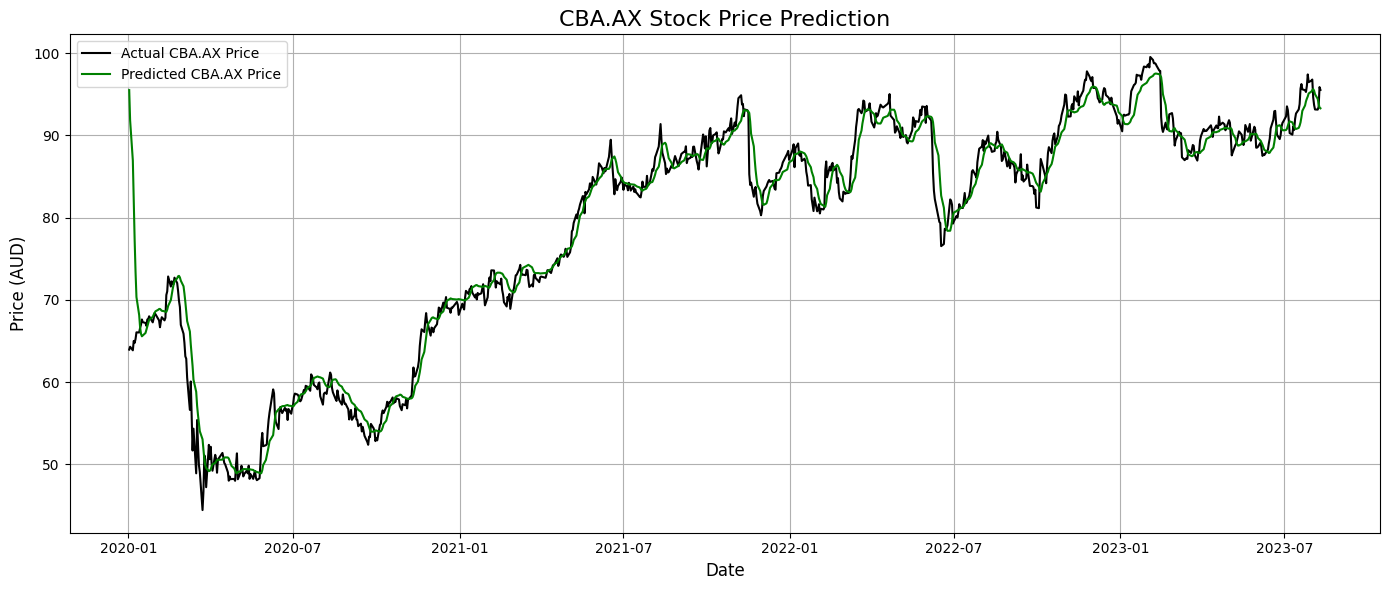

In [14]:
import matplotlib.pyplot as plt

# Plot actual vs predicted prices
plt.figure(figsize=(14, 6))

# Actual prices
plt.plot(test_data.index, actual_prices, color="black", label=f"Actual {COMPANY} Price")

# Predicted prices
plt.plot(test_data.index, predicted_prices, color="green", label=f"Predicted {COMPANY} Price")

# Optional: add markers for predicted points
# plt.scatter(test_data.index, predicted_prices, color='red', s=10, label='Predicted Points')

# Titles and labels
plt.title(f"{COMPANY} Stock Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (AUD)", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


/Users/lasithcharuka/hand/stockpred-env/lib/python3.13/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


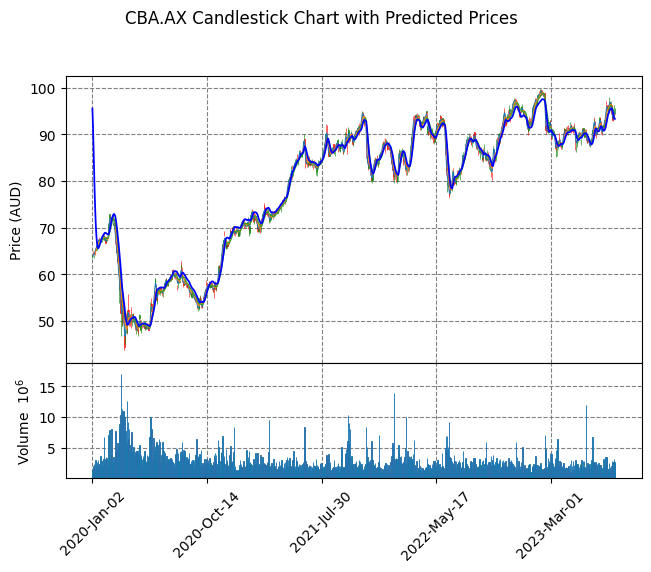

In [15]:
import mplfinance as mpf
import pandas as pd
import numpy as np

# Copy test data
ohlc_data = test_data.copy()

# Flatten MultiIndex columns if present
if isinstance(ohlc_data.columns, pd.MultiIndex):
    ohlc_data.columns = [col[0] for col in ohlc_data.columns]

# Ensure OHLC columns are numeric
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in ohlc_data.columns:
        ohlc_data[col] = pd.to_numeric(ohlc_data[col], errors='coerce')
    else:
        raise ValueError(f"Column '{col}' not found in test data!")

# Drop any rows with NaN values
ohlc_data.dropna(inplace=True)

# Align predicted prices
pred_series = pd.Series(data=predicted_prices.flatten(), index=ohlc_data.index)
ohlc_data['Predicted'] = pred_series

# Custom style
mc = mpf.make_marketcolors(up='g', down='r', edge='i', wick='i', volume='in')
s = mpf.make_mpf_style(marketcolors=mc, gridstyle='--', gridcolor='gray')

# Plot candlestick chart with predicted prices overlay
mpf.plot(
    ohlc_data,
    type='candle',
    style=s,
    title=f"{COMPANY} Candlestick Chart with Predicted Prices",
    ylabel='Price (AUD)',
    volume=True,
    mav=(3,6,9),
    addplot=mpf.make_addplot(ohlc_data['Predicted'], color='blue')
)


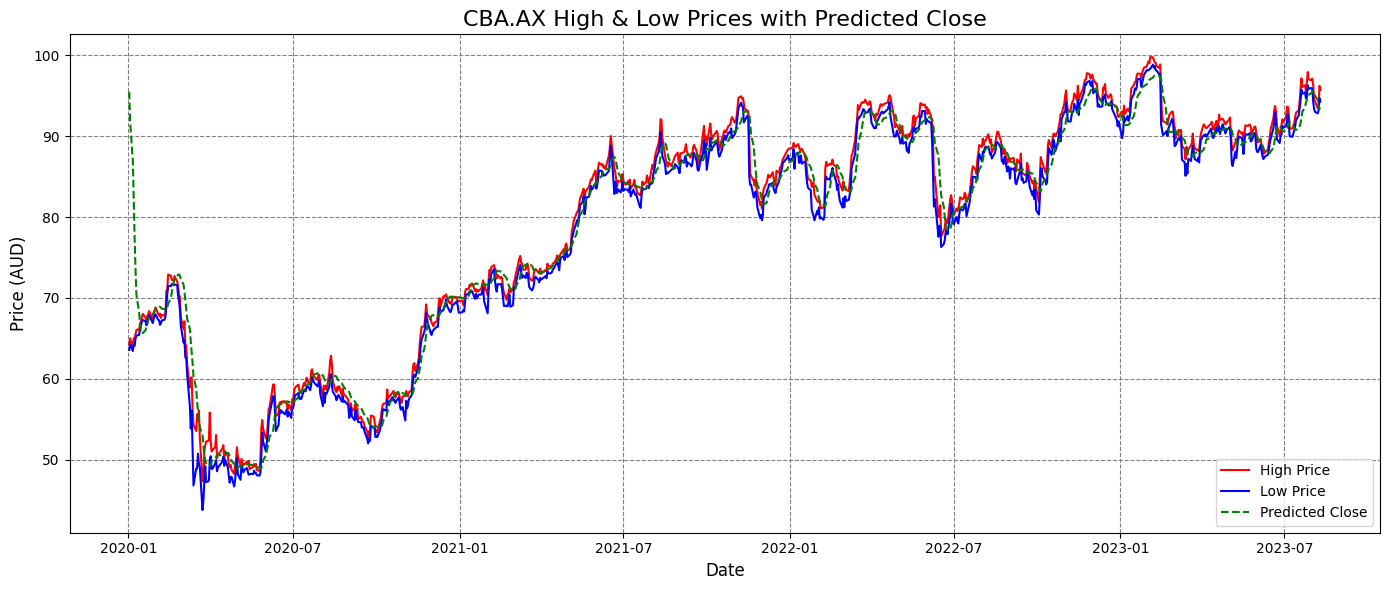

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Plot daily High prices
plt.plot(test_data.index, test_data['High'], color='red', label='High Price')

# Plot daily Low prices
plt.plot(test_data.index, test_data['Low'], color='blue', label='Low Price')

# Optional: overlay predicted Close prices
plt.plot(test_data.index, predicted_prices, color='green', linestyle='--', label='Predicted Close')

# Titles and labels
plt.title(f"{COMPANY} High & Low Prices with Predicted Close", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (AUD)", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
